# dl_08 — UNet / UNet3+ Feature Map Visualization

Runs **one** image patch through a trained model and visualizes the intermediate
feature maps at every encoder level, the bottleneck, every decoder node, and the
final logits — without modifying the model (uses PyTorch forward hooks).

**Two ways to view each level:**
- **Top-variance channels** (default): the 1–3 most spatially active channels per level — the ones actually carrying signal.
- **Mean activation map**: all channels collapsed to one image — a clean "what does this level respond to" view.

The bottleneck shows **both** side by side. There's also a whole-network mean-activation overview.

Compute is tiny: one forward pass on a single patch (runs fine on CPU).

## 1. Imports & paths

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Notebook lives in Python_Code_Analysis/DL_Pipeline_v2 — make the dl_* modules importable.
SCRIPT_DIR = Path.cwd()
sys.path.insert(0, str(SCRIPT_DIR))

# Walk up to the project root (the dir that contains Models/ and Data/).
PROJECT_ROOT = SCRIPT_DIR
while not (PROJECT_ROOT / "Models").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

MODELS_DIR = PROJECT_ROOT / "Models"
PATCHES_DIR = PROJECT_ROOT / "Data" / "Training_Data" / "R_Patches"
STATS_DIR = PROJECT_ROOT / "Data" / "Training_Data"

from dl_model_utils import load_model
from dl_02_dataset import WetlandPatchDataset

print(f"Project root: {PROJECT_ROOT}")
print(f"Models dir:   {MODELS_DIR}")
print(f"Patches dir:  {PATCHES_DIR}")

Project root: /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL
Models dir:   /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models
Patches dir:  /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Data/Training_Data/R_Patches


## 2. Choose a checkpoint

The cell below lists every `.safetensors` / `.ckpt` in `Models/`. Set
`CHECKPOINT_NAME` to whichever you want — prefer the `.safetensors` (self-describing,
no architecture flags needed).

In [2]:
# --- Available checkpoints ---
checkpoints = sorted(
    {p.name for p in MODELS_DIR.glob("*.safetensors")}
    | {p.name for p in MODELS_DIR.glob("*.ckpt")}
)
print("Available checkpoints in Models/:")
for i, name in enumerate(checkpoints):
    print(f"  [{i}] {name}")

# --- Pick one (edit this line; .safetensors preferred) ---
CHECKPOINT_NAME = "best_multiclass_unet3plus_bf64_d4_20260605_1537.safetensors"
# Or select by index instead, e.g.:
# CHECKPOINT_NAME = checkpoints[0]

CHECKPOINT_PATH = MODELS_DIR / CHECKPOINT_NAME
assert CHECKPOINT_PATH.exists(), f"Not found: {CHECKPOINT_PATH}"
print(f"\nSelected: {CHECKPOINT_NAME}")

Available checkpoints in Models/:
  [0] best_binary_bf64_d4_20260511_1527.ckpt
  [1] best_binary_bf64_d4_20260511_1527.safetensors
  [2] best_binary_unet3plus_bf64_d4_20260605_1548.ckpt
  [3] best_binary_unet3plus_bf64_d4_20260605_1548.safetensors
  [4] best_multiclass_bf128_d4_20260420_1924.safetensors
  [5] best_multiclass_bf128_d4_20260420_2139.safetensors
  [6] best_multiclass_bf128_d5_20260420_2152.safetensors
  [7] best_multiclass_bf32_d4_20260510_2014.ckpt
  [8] best_multiclass_bf64_d4_20260420_0134.safetensors
  [9] best_multiclass_bf64_d4_20260420_0209.safetensors
  [10] best_multiclass_bf64_d4_20260420_0230.safetensors
  [11] best_multiclass_bf64_d4_20260420_0245.safetensors
  [12] best_multiclass_bf64_d4_20260420_0304.safetensors
  [13] best_multiclass_bf64_d4_20260420_2239.safetensors
  [14] best_multiclass_bf64_d4_20260511_1543.ckpt
  [15] best_multiclass_bf64_d4_20260511_1543.safetensors
  [16] best_multiclass_bf64_d5_20260420_2226.safetensors
  [17] best_multiclass_unet3

## 3. Visualization settings

In [4]:
# How many top-variance channels to show per level (1-3 recommended).
CHANNELS_PER_LEVEL = 3

# Colormap for feature-map heatmaps.
FEATURE_CMAP = "viridis"

# Run on CPU by default (one patch is sub-second; deterministic + no device quirks).
# Switch to the line below to use GPU/MPS if you prefer.
DEVICE = torch.device("mps")
# from dl_03_unet_model import get_device; DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## 4. Load the model

`load_model()` reads the architecture straight from the `.safetensors` sidecar
(`.meta.json`) or the `.ckpt` hyperparameters, so no architecture flags are needed.

In [5]:
# in_channels / num_classes here are fallbacks only; for .safetensors/.ckpt they're
# overridden by the checkpoint metadata.
model = load_model(
    CHECKPOINT_PATH,
    device=DEVICE,
    in_channels=26,
    num_classes=4,
)
model.eval()

DEPTH = model.depth
NUM_CLASSES = model.num_classes
ARCH = type(model).__name__
print(f"\nArchitecture: {ARCH}, depth={DEPTH}, num_classes={NUM_CLASSES}")

# Class names + classification mode: prefer the checkpoint's .meta.json sidecar.
meta_path = CHECKPOINT_PATH.with_suffix(".meta.json")
if meta_path.exists():
    meta = json.loads(meta_path.read_text())
    CLASS_NAMES = meta.get("class_names", [f"class_{i}" for i in range(NUM_CLASSES)])
    MODE = meta.get("classification_mode", "multiclass")
else:
    CLASS_NAMES = [f"class_{i}" for i in range(NUM_CLASSES)]
    MODE = "multiclass"
print(f"Classes: {CLASS_NAMES}  (mode={MODE})")

Loaded model from /Users/Anthony/Data and Analysis Local/NYS_Wetlands_DL/Models/best_multiclass_unet3plus_bf64_d4_20260605_1537.safetensors (safetensors)
  Architecture: unet3plus(in=26, bf=64, depth=4)
  Epoch: 29

Architecture: UNet3Plus, depth=4, num_classes=4
Classes: ['EMW', 'FSW', 'SSW', 'UPL']  (mode=multiclass)


## 5. Choose a patch & normalize it

Uses the same `WetlandPatchDataset` normalization as training so the inputs match
what the model saw. The stats file is selected to match the checkpoint's mode.

In [6]:
# --- Stats file (normalization is identical across weight-power variants) ---
stats_candidates = [
    STATS_DIR / f"{MODE}_normalization_stats.json",
    STATS_DIR / f"{MODE}_normalization_stats_wp0.5.json",
    STATS_DIR / "normalization_stats.json",
]
STATS_PATH = next((p for p in stats_candidates if p.exists()), None)
assert STATS_PATH is not None, f"No stats file found. Looked for: {stats_candidates}"
print(f"Stats: {STATS_PATH.name}")

# --- Pick a patch (edit PATCH_NAME, or use a random one) ---
patch_files = sorted(PATCHES_DIR.glob("*.tif"))
print(f"{len(patch_files)} patches available. First few:")
for p in patch_files[:3]:
    print(f"  {p.name}")

Stats: multiclass_normalization_stats.json
480 patches available. First few:
  ADK_cluster_11_huc_042900030103_patch_10_256m.tif
  ADK_cluster_11_huc_042900030103_patch_11_256m.tif
  ADK_cluster_11_huc_042900030103_patch_12_256m.tif


In [8]:
PATCH_NAME = "gps_cluster_225_huc_043001060201_patch_2_256m.tif"#patch_files[0].name
# Random instead: PATCH_NAME = np.random.RandomState(0).choice([p.name for p in patch_files])
PATCH_PATH = PATCHES_DIR / PATCH_NAME
assert PATCH_PATH.exists(), f"Not found: {PATCH_PATH}"
print(f"\nSelected patch: {PATCH_NAME}")


Selected patch: gps_cluster_225_huc_043001060201_patch_2_256m.tif


In [9]:
# Normalize the patch exactly as the training pipeline does.
ds = WetlandPatchDataset([PATCH_PATH], STATS_PATH, augment=False, validate_bands=False)
predictors, labels = ds[0]            # (in_channels, H, W), (H, W)
x = predictors.unsqueeze(0).to(DEVICE)  # add batch dim
labels = labels.numpy()
print(f"Input tensor: {tuple(x.shape)}, dtype={x.dtype}")
print(f"Label unique: {np.unique(labels).tolist()}  (255 = unlabeled)")

# Raw NAIP RGB for a visual reference (read straight from the GeoTIFF, 0-255).
with rasterio.open(PATCH_PATH) as src:
    band_names = list(src.descriptions)
    def _read(name):
        return src.read(band_names.index(name) + 1).astype(np.float32)
    try:
        rgb = np.dstack([_read("r"), _read("g"), _read("b")]) / 255.0
        rgb = np.clip(np.nan_to_num(rgb), 0, 1)
    except ValueError:
        rgb = None  # r/g/b not present in this patch
print(f"Bands in patch: {band_names}")

Input tensor: (1, 26, 256, 256), dtype=torch.float32
Label unique: [0, 1, 2, 3]  (255 = unlabeled)
Bands in patch: ['DEM', 'slope_local', 'Geomorph_local', 'flowacc', 'twi', 'CHM', 'r', 'g', 'b', 'nir', 'r_lo', 'g_lo', 'b_lo', 'nir_lo', 'pct_below_1m', 'pct_1m_to_5m', 'pct_above_5m', 'MOD_CLASS']


## 6. Register forward hooks & run the patch

Hooks tap each submodule's output without touching the model:
- `encoders[i]` → returns `(pooled, skip)`; we keep the **skip** (full feature map at level *i*)
- `bottleneck` → coarsest feature map
- `fuse_se[idx]` → fused full-scale decoder node (UNet3+); for plain UNet we fall back to decoder blocks
- `head` → class logits

In [10]:
features = {}   # name -> (C, H, W) numpy array for the single patch
hooks = []

def _cap(name, take_skip=False):
    def hook(module, inp, out):
        t = out[1] if take_skip else out
        features[name] = t.detach().cpu().float().numpy()[0]
    return hook

# Encoder levels (skip = pre-downsample feature at that level's resolution).
for i, enc in enumerate(model.encoders):
    hooks.append(enc.register_forward_hook(_cap(f"enc{i}", take_skip=True)))

# Bottleneck (captured pre-dropout; dropout is identity in eval anyway).
hooks.append(model.bottleneck.register_forward_hook(_cap("bottleneck")))

# Decoder nodes.
if hasattr(model, "fuse_se"):  # UNet3+
    for idx, lvl in enumerate(model._decoder_levels):
        hooks.append(model.fuse_se[idx].register_forward_hook(_cap(f"dec{lvl}")))
elif hasattr(model, "decoders"):  # plain UNet
    for idx, dec in enumerate(model.decoders):
        lvl = (DEPTH - 1) - idx
        hooks.append(dec.register_forward_hook(_cap(f"dec{lvl}")))

# Final logits.
head = model.head if hasattr(model, "head") else model.output
hooks.append(head.register_forward_hook(_cap("logits")))

# Forward pass (deep-supervision models return a single tensor in eval mode).
with torch.no_grad():
    out = model(x)
if isinstance(out, (list, tuple)):
    out = out[0]

for h in hooks:
    h.remove()

print("Captured feature maps (name: channels x H x W):")
for k, v in features.items():
    print(f"  {k:12s} {v.shape[0]:4d} x {v.shape[1]:3d} x {v.shape[2]:3d}")

Captured feature maps (name: channels x H x W):
  enc0           64 x 256 x 256
  enc1          128 x 128 x 128
  enc2          256 x  64 x  64
  enc3          512 x  32 x  32
  bottleneck   1024 x  16 x  16
  dec3          320 x  32 x  32
  dec2          320 x  64 x  64
  dec1          320 x 128 x 128
  dec0          320 x 256 x 256
  logits          4 x 256 x 256


## 7. Plot helpers

In [11]:
def norm01(a):
    """Min-max a 2D map to [0,1] for display (constant maps -> zeros)."""
    a = np.nan_to_num(a.astype(np.float32))
    lo, hi = float(a.min()), float(a.max())
    return (a - lo) / (hi - lo) if hi > lo else np.zeros_like(a)

def top_variance_channels(fmap, k):
    """Indices of the k channels with the highest spatial variance."""
    var = fmap.reshape(fmap.shape[0], -1).var(axis=1)
    return np.argsort(var)[::-1][:k]

def plot_levels(level_keys, k=CHANNELS_PER_LEVEL, mode="variance", suptitle=""):
    """Grid of feature maps: one row per level.

    mode='variance' -> k top-variance channels per row.
    mode='mean'     -> single mean-activation map per row.
    """
    keys = [kk for kk in level_keys if kk in features]
    ncols = k if mode == "variance" else 1
    fig, axes = plt.subplots(len(keys), ncols, figsize=(3.0 * ncols, 3.0 * len(keys)),
                             squeeze=False)
    for r, key in enumerate(keys):
        fmap = features[key]
        C, H, W = fmap.shape
        if mode == "variance":
            for c, ci in enumerate(top_variance_channels(fmap, k)):
                ax = axes[r][c]
                ax.imshow(norm01(fmap[ci]), cmap=FEATURE_CMAP)
                ax.set_title(f"{key}  ch{ci}\n{C}ch @ {H}x{W}", fontsize=8)
                ax.axis("off")
        else:
            ax = axes[r][0]
            ax.imshow(norm01(fmap.mean(axis=0)), cmap=FEATURE_CMAP)
            ax.set_title(f"{key}  mean of {C}ch\n{H}x{W}", fontsize=8)
            ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=12, y=1.0)
    fig.tight_layout()
    plt.show()

## 8. Input reference

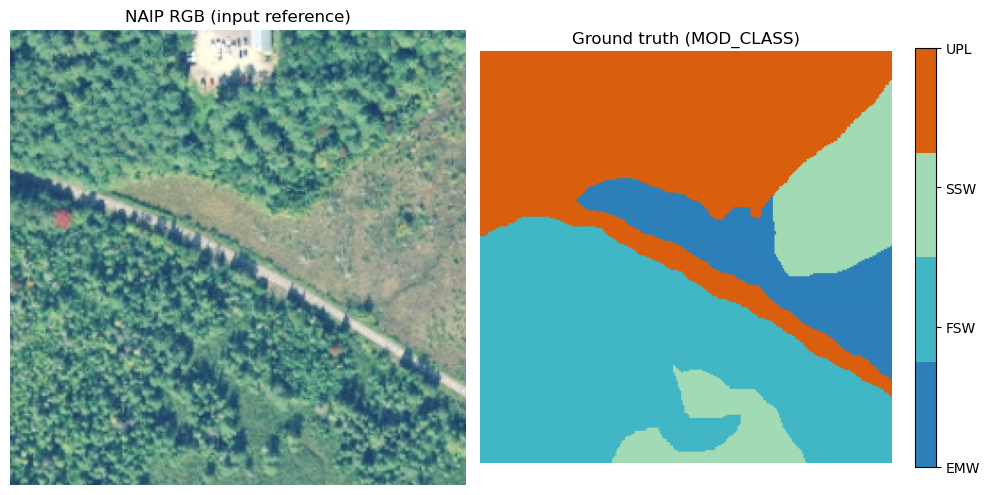

In [12]:
# Class colormap (extend the palette if you have >5 classes).
_palette = ["#2c7fb8", "#41b6c4", "#a1dab4", "#d95f0e", "#756bb1", "#636363"]
CLASS_CMAP = ListedColormap(_palette[:NUM_CLASSES])

ncols = 2 if rgb is not None else 1
fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), squeeze=False)
col = 0
if rgb is not None:
    axes[0][col].imshow(rgb)
    axes[0][col].set_title("NAIP RGB (input reference)")
    axes[0][col].axis("off")
    col += 1
lbl_disp = np.ma.masked_equal(labels, 255)
im = axes[0][col].imshow(lbl_disp, cmap=CLASS_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
axes[0][col].set_title("Ground truth (MOD_CLASS)")
axes[0][col].axis("off")
cbar = fig.colorbar(im, ax=axes[0][col], fraction=0.046, ticks=range(NUM_CLASSES))
cbar.ax.set_yticklabels(CLASS_NAMES)
fig.tight_layout()
plt.show()

## 8b. All input bands — interactive Leaflet map (folium)

Every predictor band rendered as a georeferenced overlay on a Leaflet basemap.
Use the **radio control (top-right)** to toggle through bands one at a time.
Overlays are embedded in the notebook (work offline); only the basemap tiles need internet.

Each band gets a percentile (2–98%) contrast stretch and its own colormap; nodata is transparent.

In [ ]:
import io
import base64
from PIL import Image
import matplotlib
import folium
from folium.plugins import GroupedLayerControl
from rasterio.warp import transform_bounds

# Per-band colormaps (anything unlisted falls back to viridis).
BAND_CMAPS = {
    "DEM": "gist_earth", "slope_local": "magma", "twi": "Blues",
    "flowacc": "Blues", "CHM": "YlGn", "Geomorph_local": "tab20",
    "pct_below_1m": "YlGn", "pct_1m_to_5m": "YlGn", "pct_above_5m": "YlGn",
}

def band_to_datauri(arr, cmap_name, nodata=None, pct=(2, 98)):
    """Render a single band to a base64 PNG data URI (nodata -> transparent)."""
    a = arr.astype(np.float32)
    mask = np.isnan(a)
    if nodata is not None and not np.isnan(nodata):
        mask |= (a == nodata)
    valid = a[~mask]
    lo, hi = (np.percentile(valid, pct) if valid.size else (0.0, 1.0))
    if hi <= lo:
        hi = lo + 1e-6
    norm = np.clip((a - lo) / (hi - lo), 0, 1)
    rgba = (matplotlib.colormaps[cmap_name](norm) * 255).astype(np.uint8)
    rgba[mask, 3] = 0  # transparent nodata
    buf = io.BytesIO()
    Image.fromarray(rgba, mode="RGBA").save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

# Read every band + reproject the patch bounds to lat/lon for Leaflet.
with rasterio.open(PATCH_PATH) as src:
    all_bands = list(src.descriptions)
    nodata = src.nodata
    raster = src.read()
    west, south, east, north = transform_bounds(src.crs, "EPSG:4326", *src.bounds)

bounds_latlon = [[south, west], [north, east]]
LABEL_BAND = ds.label_band  # exclude the label band from the input overlays
display_bands = [b for b in all_bands if b != LABEL_BAND]

m = folium.Map(
    location=[(south + north) / 2, (west + east) / 2],
    zoom_start=15,
    tiles="OpenStreetMap",
)

# One FeatureGroup per band; GroupedLayerControl makes them an exclusive (radio) set.
groups = []
for i, band in enumerate(display_bands):
    arr = raster[all_bands.index(band)]
    uri = band_to_datauri(arr, BAND_CMAPS.get(band, "viridis"), nodata)
    fg = folium.FeatureGroup(name=band, show=(i == 0))
    folium.raster_layers.ImageOverlay(image=uri, bounds=bounds_latlon, opacity=0.85).add_to(fg)
    fg.add_to(m)
    groups.append(fg)

GroupedLayerControl(
    groups={"Input bands": groups},
    exclusive_groups=True,
    collapsed=False,
).add_to(m)
m.fit_bounds(bounds_latlon)
print(f"Built Leaflet map with {len(display_bands)} band overlays: {display_bands}")
m

## 9. Encoder feature maps (top-variance channels)

Rows go fine → coarse (`enc0` = full resolution, deeper rows are downsampled).

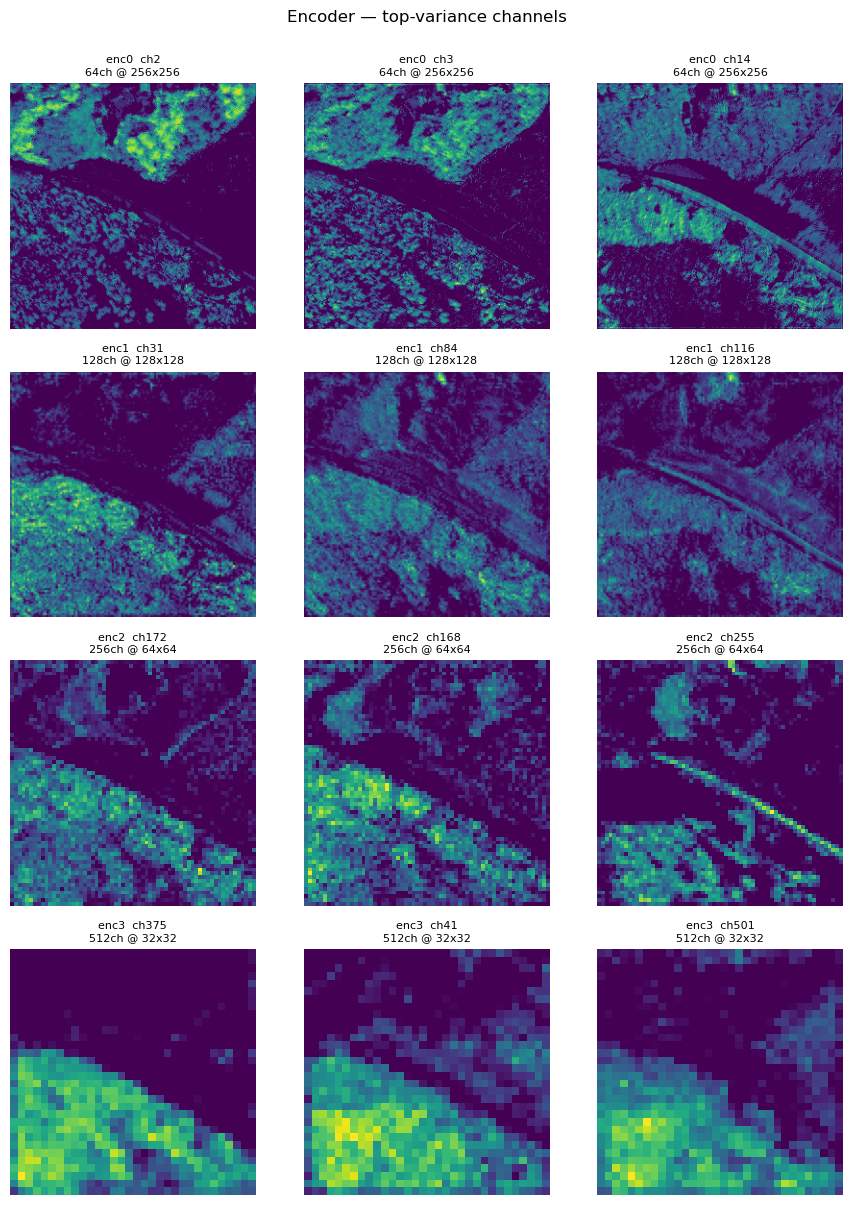

In [13]:
enc_keys = [f"enc{i}" for i in range(DEPTH)]
plot_levels(enc_keys, mode="variance", suptitle="Encoder — top-variance channels")

## 10. Bottleneck — BOTH views

Top-variance channels **and** the mean-activation map, side by side. This is the
widest level (hundreds of channels), so the mean view is the most readable summary.

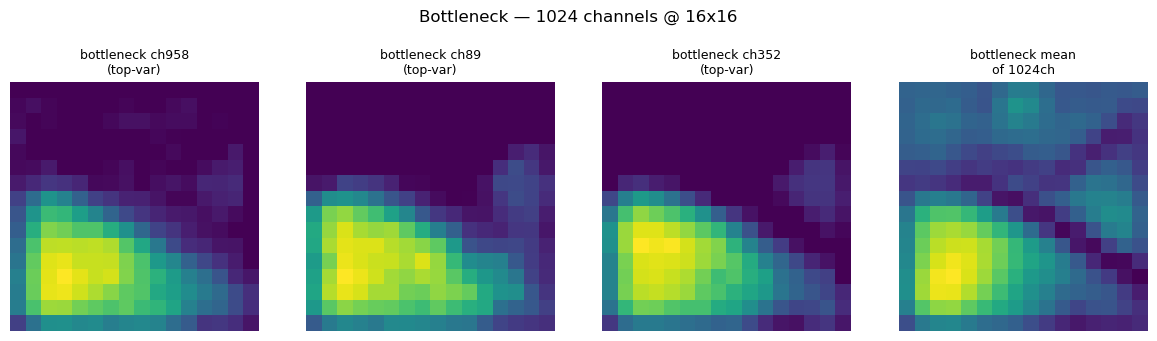

In [14]:
bn = features["bottleneck"]
C, H, W = bn.shape
k = CHANNELS_PER_LEVEL
fig, axes = plt.subplots(1, k + 1, figsize=(3.0 * (k + 1), 3.2), squeeze=False)

# Top-variance channels.
for c, ci in enumerate(top_variance_channels(bn, k)):
    axes[0][c].imshow(norm01(bn[ci]), cmap=FEATURE_CMAP)
    axes[0][c].set_title(f"bottleneck ch{ci}\n(top-var)", fontsize=9)
    axes[0][c].axis("off")

# Mean activation across all channels.
axes[0][k].imshow(norm01(bn.mean(axis=0)), cmap=FEATURE_CMAP)
axes[0][k].set_title(f"bottleneck mean\nof {C}ch", fontsize=9)
axes[0][k].axis("off")

fig.suptitle(f"Bottleneck — {C} channels @ {H}x{W}", fontsize=12, y=1.05)
fig.tight_layout()
plt.show()

## 11. Decoder feature maps (top-variance channels)

Rows go coarse → fine (`dec0` = full-resolution node feeding the output head).

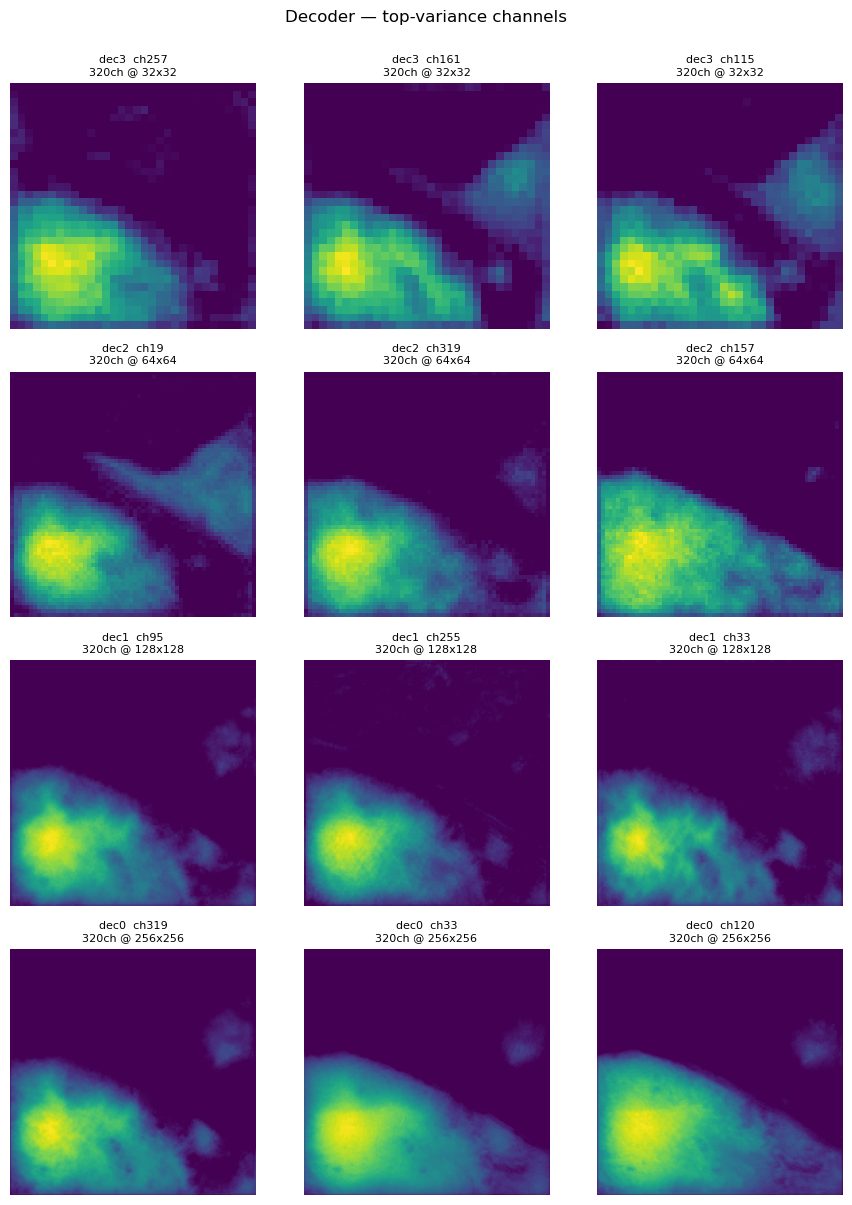

In [15]:
dec_keys = [f"dec{i}" for i in range(DEPTH - 1, -1, -1)]
plot_levels(dec_keys, mode="variance", suptitle="Decoder — top-variance channels")

## 12. Whole-network mean-activation overview

One mean map per level, encoder → bottleneck → decoder, for a quick "signal flow"
read of the entire forward pass.

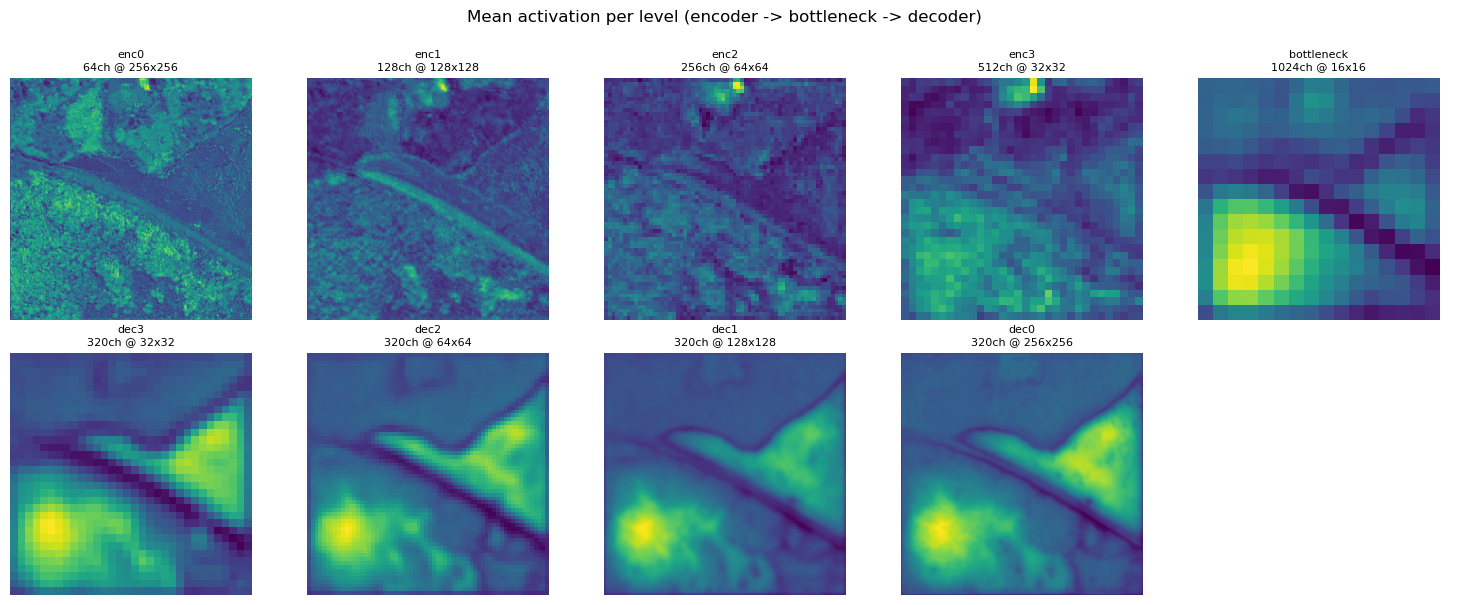

In [16]:
overview_keys = (
    [f"enc{i}" for i in range(DEPTH)]
    + ["bottleneck"]
    + [f"dec{i}" for i in range(DEPTH - 1, -1, -1)]
)
overview_keys = [k for k in overview_keys if k in features]
ncols = 5
nrows = int(np.ceil(len(overview_keys) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.0 * nrows), squeeze=False)
for ax in axes.ravel():
    ax.axis("off")
for idx, key in enumerate(overview_keys):
    fmap = features[key]
    ax = axes[idx // ncols][idx % ncols]
    ax.imshow(norm01(fmap.mean(axis=0)), cmap=FEATURE_CMAP)
    ax.set_title(f"{key}\n{fmap.shape[0]}ch @ {fmap.shape[1]}x{fmap.shape[2]}", fontsize=8)
    ax.axis("off")
fig.suptitle("Mean activation per level (encoder -> bottleneck -> decoder)", fontsize=12, y=1.0)
fig.tight_layout()
plt.show()

## 13. Logits → predicted classes

Per-class softmax probability heatmaps, the `argmax` prediction, and the ground
truth for comparison.

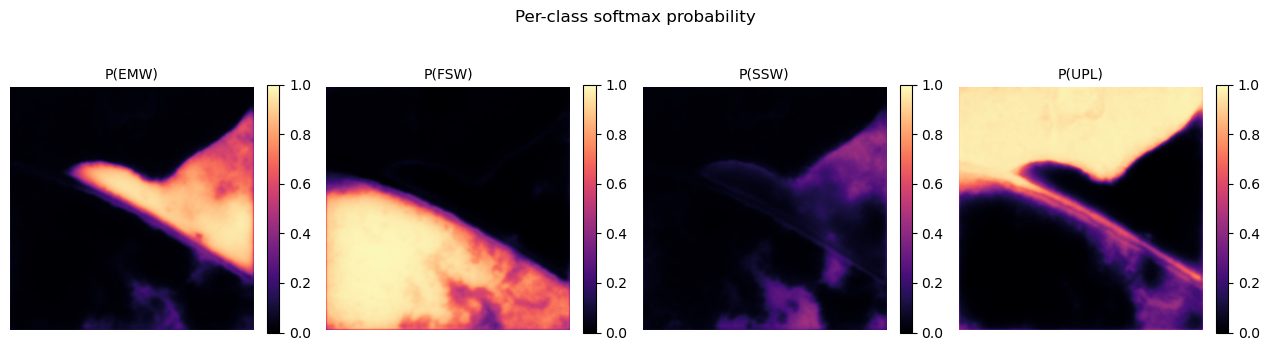

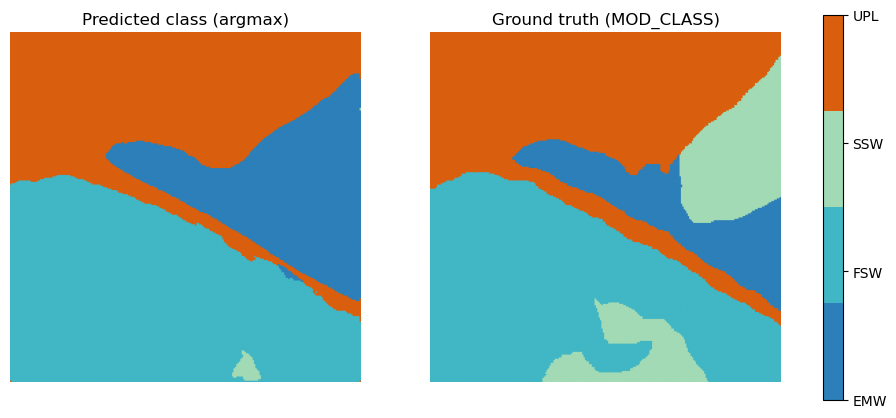

In [17]:
probs = torch.softmax(out, dim=1)[0].cpu().numpy()  # (num_classes, H, W)
pred = probs.argmax(axis=0)

# Per-class probability heatmaps.
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(3.2 * NUM_CLASSES, 3.4), squeeze=False)
for c in range(NUM_CLASSES):
    im = axes[0][c].imshow(probs[c], cmap="magma", vmin=0, vmax=1)
    axes[0][c].set_title(f"P({CLASS_NAMES[c]})", fontsize=10)
    axes[0][c].axis("off")
    fig.colorbar(im, ax=axes[0][c], fraction=0.046)
fig.suptitle("Per-class softmax probability", fontsize=12, y=1.04)
fig.tight_layout()
plt.show()

# Prediction vs. ground truth.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
im0 = axes[0].imshow(pred, cmap=CLASS_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
axes[0].set_title("Predicted class (argmax)")
axes[0].axis("off")
axes[1].imshow(np.ma.masked_equal(labels, 255), cmap=CLASS_CMAP, vmin=0, vmax=NUM_CLASSES - 1)
axes[1].set_title("Ground truth (MOD_CLASS)")
axes[1].axis("off")
cbar = fig.colorbar(im0, ax=axes, fraction=0.046, ticks=range(NUM_CLASSES))
cbar.ax.set_yticklabels(CLASS_NAMES)
plt.show()

---
**To explore another patch or model:** change `CHECKPOINT_NAME` (cell 2) or
`PATCH_NAME` (cell 5), then re-run from that cell down. Adjust `CHANNELS_PER_LEVEL`
(cell 3) to show more/fewer channels per level.